# PN2V (Probabilistic Noise2Void) — training & benchmarking

Trains **Probabilistic Noise2Void** (Krull et al., *Front. Comput. Sci.* 2020) on the Cy3 training video and denoises the same test set used for N2V / DeepCAD-RT, so it can be added to the benchmark.

The notebook saves: **training + validation curves, the full config / hyper-parameter record, hardware specs, and wall-clock training time**, plus the noise-model figure and all model checkpoints.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 Cell 0: Initial Setup & Data Loading

In [ ]:
# We use the authors' official implementation: https://github.com/juglab/pn2v
# torch / torchvision are already provided by Colab, so we deliberately do NOT
# reinstall them (this avoids CUDA / driver mismatches).

print("--- Installing the official PN2V package (pinned commit) + utilities... ---")
!pip install --quiet "git+https://github.com/juglab/pn2v.git@9b7e0f4c3cc6c1c878caff1121585aa15d2f6a33" tifffile matplotlib scipy tqdm

print("\n\n If the git install fails, clone + install instead:")
print("   !git clone https://github.com/juglab/pn2v.git /content/pn2v && pip install -q /content/pn2v")
print("\n\n Installation complete. Please RESTART the session now (Runtime -> Restart session).")

--- Installing the official PN2V package (pinned commit) + utilities... ---
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


 If the git install fails, clone + install instead:
   !git clone https://github.com/juglab/pn2v.git /content/pn2v && pip install -q /content/pn2v


 Installation complete. Please RESTART the session now (Runtime -> Restart session).


Cell 1: Imports, Paths & Configuration

In [ ]:
import os, sys, json, time, platform
import numpy as np
import tifffile
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

import torch
import torchvision

import torch.nn.init as _init
if not hasattr(_init, "xavier_normal"): _init.xavier_normal = _init.xavier_normal_
if not hasattr(_init, "constant"):      _init.constant     = _init.constant_

from pn2v.unet import UNet
from pn2v import utils, histNoiseModel, training, prediction

device = utils.getDevice()
print(f"Torch {torch.__version__} | Torchvision {torchvision.__version__} | Device: {device}")

def pad_to_divisible(image_stack, divisor=16):
    num_frames, h, w = image_stack.shape
    pad_h = (divisor - h % divisor) % divisor
    pad_w = (divisor - w % divisor) % divisor
    if pad_h == 0 and pad_w == 0: return image_stack, (0, 0, 0, 0)
    pad_top, pad_bottom = pad_h // 2, pad_h - (pad_h // 2)
    pad_left, pad_right = pad_w // 2, pad_w - (pad_w // 2)
    print(f"Padding HxW from {h}x{w} to {h+pad_h}x{w+pad_w}.")
    padded_stack = np.pad(image_stack, ((0, 0), (pad_top, pad_bottom), (pad_left, pad_right)), mode='reflect')
    return padded_stack, (pad_top, pad_bottom, pad_left, pad_right)

def crop_padded_stack(padded_stack, spatial_pads):
    if not any(spatial_pads): return padded_stack
    pad_top, pad_bottom, pad_left, pad_right = spatial_pads
    h_new, w_new = padded_stack.shape[1], padded_stack.shape[2]
    crop_y_end = h_new - pad_bottom if pad_bottom > 0 else h_new
    crop_x_end = w_new - pad_right if pad_right > 0 else w_new
    return padded_stack[:, pad_top:crop_y_end, pad_left:crop_x_end]

def pad2d_reflect(img, divisor):
    h, w = img.shape
    ph = (divisor - h % divisor) % divisor
    pw = (divisor - w % divisor) % divisor
    t, b = ph // 2, ph - ph // 2
    l, r = pw // 2, pw - pw // 2
    return np.pad(img, ((t, b), (l, r)), mode='reflect'), (t, b, l, r)

def unpad2d(img, pads):
    t, b, l, r = pads
    H, W = img.shape
    return img[t:(H - b) if b > 0 else H, l:(W - r) if r > 0 else W]

# --- PN2V configuration (all hyper-parameters in one place) ---
CONFIG = {
    # --- Network architecture (PN2V defaults from the official examples) ---
    "net_depth":            3,      # U-Net depth (Convallaria / Mouse examples use 3)
    "num_samples":          800,    # U-Net output channels = samples from the predicted prior

    # --- N2V-style pixel masking ---
    "patch_size":           64,     # training patch size (auto-shrunk to fit small images / U-Net depth)
    "n2v_perc_pix":         1.6,    # % of pixels masked per patch (official trainPN2V.py default)

    # --- Optimisation (shared by both training stages) ---
    "batch_size":           4,
    "virtual_batch_size":   20,
    "learning_rate":        1e-3,
    "val_size":             20,     # validation patches evaluated per epoch
    "augment":              True,

    # --- Stage 1: bootstrap N2V network (used ONLY to estimate the noise model) ---
    "bootstrap_epochs":     100,
    "bootstrap_steps":      20,

    # --- Stage 2: the PN2V network we benchmark ---
    "pn2v_epochs":          200,
    "pn2v_steps":           20,

    # --- Histogram noise model ---
    "nm_bins":              128,
    "nm_min":               None,   # None -> training_frames.min()
    "nm_max":               800,   # None -> training_frames.max()
    "nm_max_frames":        200,    # cap on #frames used to BUILD the histogram

    # --- Data / inference ---
    "val_fraction":         0.10,   # last 10% of frames used for validation (matche the N2V notebook)
    "save_prior_output":    True,
}


TRAIN_TIFF_PATH = "/content/drive/MyDrive/DATA_ROOT/exp_data2/Cy3_Best/Cy3_Best.tif"

"""
TEST_TIFF_PATHS = [
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/30_Green/30_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/29_Green/29_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/20_Green/20_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/19_Green/19_Green.tif",
    "/content/drive/MyDrive/DATA_ROOT/exp_data2/Cy3_Best/Cy3_Best.tif"
]
"""
TEST_TIFF_PATHS = [
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_1.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_2.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_3.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_4.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_5.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_6.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_7.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_8.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_9.00.tif",
    "/content/drive/MyDrive/DATA_ROOT/sim_data_paper_v2/sim_Gauss_Poisson_Est_scale_10.00.tif"
]


OUTPUT_DIR = "/content/drive/MyDrive/DATA_ROOT/exp_data3"
os.makedirs(OUTPUT_DIR, exist_ok=True)
PN2V_MODEL_DIR = os.path.join(OUTPUT_DIR, "PN2V_model")
os.makedirs(PN2V_MODEL_DIR, exist_ok=True)

PAD_DIV = 2 ** (CONFIG["net_depth"] - 1)
print(f"Artifacts (models, logs, configs, curves) -> {PN2V_MODEL_DIR}")

print(f"\nLoading TRAINING video from: {TRAIN_TIFF_PATH}")
try:
    training_frames = tifffile.imread(TRAIN_TIFF_PATH).astype(np.float32)
    if training_frames.ndim == 2:
        training_frames = training_frames[np.newaxis, ...]
    print(f" Successfully loaded training stack with shape: {training_frames.shape}")
except Exception as e:
    print(f" Error loading training TIFF file: {e}")
    training_frames = None

CUDA available? True
Torch 2.11.0+cu128 | Torchvision 0.26.0+cu128 | Device: cuda
Artifacts (models, logs, configs, curves) -> /content/drive/MyDrive/DATA_ROOT/exp_data3/PN2V_model

Loading TRAINING video from: /content/drive/MyDrive/DATA_ROOT/exp_data2/Cy3_Best/Cy3_Best.tif
 Successfully loaded training stack with shape: (916, 256, 256)


### Noise-model strategy

PN2V needs a **pixel noise model** `p(x|s)` — the probability of observing intensity `x` given the true signal `s`. The official examples build it by imaging a **static** sample many times and averaging to get the clean signal.

**That does not work for our data.** Single-molecule TIRF frames contain blinking / moving spots, so a temporal average is not a valid clean signal — spots would smear into ghosts and corrupt the model.

Instead we use the **bootstrapping** procedure from the PN2V paper (the standard fix when no calibration / static data exists):

1. **Stage 1** — train a plain **N2V** network on the raw data (needs no noise model);
2. use its per-frame output as a **pseudo-clean signal** estimate;
3. build the **histogram noise model** from `(raw, pseudo-clean)` pixel pairs;
4. **Stage 2** — train the **PN2V** network with that noise model.

Cell 2: Stage 1 — Bootstrap N2V network (to estimate the noise model)

In [ ]:
import inspect, torch.optim.lr_scheduler as _lrs
if "verbose" not in inspect.signature(_lrs.ReduceLROnPlateau.__init__).parameters:
    _R = _lrs.ReduceLROnPlateau
    class _RC(_R):
        def __init__(self, *a, **k):
            k.pop("verbose", None)
            super().__init__(*a, **k)
    _lrs.ReduceLROnPlateau = _RC
print("ReduceLROnPlateau patched:", _lrs.ReduceLROnPlateau.__name__)

ReduceLROnPlateau patched: _RC


In [ ]:
if training_frames is None:
    print(" Training frames not found. Run Cell 1 first.")
else:
    N, H, W = training_frames.shape

    mult = 2 ** (CONFIG["net_depth"] - 1)
    ps = min(CONFIG["patch_size"], H, W)
    ps = (ps // mult) * mult
    assert ps >= mult, f"Images too small ({H}x{W}) for net_depth={CONFIG['net_depth']}."
    if ps != CONFIG["patch_size"]:
        print(f" Adjusted patch_size {CONFIG['patch_size']} -> {ps} to fit images / U-Net depth.")
    CONFIG["patch_size_effective"] = ps
    CONFIG["num_masked_pixels"] = int(round(ps * ps * CONFIG["n2v_perc_pix"] / 100.0))

    split = max(1, int(N * (1.0 - CONFIG["val_fraction"])))
    train_data = training_frames[:split].copy()
    val_data   = training_frames[split:].copy()
    if val_data.shape[0] == 0:
        val_data = training_frames[-1:].copy()
    print(f"Data split -> train: {train_data.shape}, val: {val_data.shape}")
    print(f"Patch: {ps}x{ps} | masked pixels/patch: {CONFIG['num_masked_pixels']}")

    torch.manual_seed(0); np.random.seed(0)
    boot_net = UNet(1, depth=CONFIG["net_depth"])

    print("\n--- Training bootstrap N2V network (Stage 1)... ---")
    t0 = time.perf_counter()
    boot_train_hist, boot_val_hist = training.trainNetwork(
        net=boot_net, trainData=train_data, valData=val_data,
        noiseModel=None,
        postfix="pn2v_bootstrap", directory=PN2V_MODEL_DIR, device=device,
        numOfEpochs=CONFIG["bootstrap_epochs"], stepsPerEpoch=CONFIG["bootstrap_steps"],
        batchSize=CONFIG["batch_size"], patchSize=ps,
        numMaskedPixels=CONFIG["num_masked_pixels"], virtualBatchSize=CONFIG["virtual_batch_size"],
        valSize=CONFIG["val_size"], learningRate=CONFIG["learning_rate"],
        augment=CONFIG["augment"],
    )
    boot_time_s = time.perf_counter() - t0
    print(f" Bootstrap training done in {boot_time_s/60:.1f} min.")

    n_hist = min(N, CONFIG["nm_max_frames"])
    hist_idx = np.unique(np.linspace(0, N - 1, n_hist).astype(int))
    print(f"\n--- Estimating pseudo-clean signal on {len(hist_idx)} frames (for the noise model)... ---")

    N = training_frames.shape[0]
    boot_net.train(False)
    obs_list, sig_list = [], []
    for k in tqdm(np.arange(N)):
        raw = training_frames[k]
        padded, pads = pad2d_reflect(raw, PAD_DIV)
        with torch.no_grad():
            means, _ = prediction.predict(padded, boot_net, None, device, outScaling=10.0)
        obs_list.append(raw); sig_list.append(unpad2d(means, pads))
    bootstrap_obs    = np.array(obs_list, dtype=np.float32)
    bootstrap_signal = np.array(sig_list, dtype=np.float32)
    print("pairs from", bootstrap_obs.shape[0], "frames")
    print(f" Pseudo-clean signal ready: {bootstrap_signal.shape}")

Data split -> train: (824, 256, 256), val: (92, 256, 256)
Patch: 64x64 | masked pixels/patch: 66

--- Training bootstrap N2V network (Stage 1)... ---
Epoch 0 finished      
avg. loss: 1.010749191045761+-(2SEM)0.0716862844288968      
Epoch 1 finished      
avg. loss: 0.9698359251022339+-(2SEM)0.0612943863756015      
Epoch 2 finished      
avg. loss: 0.9659844219684601+-(2SEM)0.06862153916923075      
Epoch 3 finished      
avg. loss: 0.9122217804193496+-(2SEM)0.05944098223579412      
Epoch 4 finished      
avg. loss: 0.9483033418655396+-(2SEM)0.07629732733673146      
Epoch 5 finished      
avg. loss: 0.9427651733160018+-(2SEM)0.06544756240702099      
Epoch 6 finished      
avg. loss: 0.9211164325475693+-(2SEM)0.05592063313528359      
Epoch 7 finished      
avg. loss: 0.9115407586097717+-(2SEM)0.05088742976735637      
Epoch 8 finished      
avg. loss: 0.9264344066381455+-(2SEM)0.05549887168015219      
Epoch 9 finished      
avg. loss: 0.9181793302297592+-(2SEM)0.05103525682682128

  0%|          | 0/916 [00:00<?, ?it/s]

pairs from 916 frames
 Pseudo-clean signal ready: (916, 256, 256)


Cell 3: Build the histogram noise model  p(x|s)

Noise model: bins=128, range=[117.0, 800.0], from 916 (raw, pseudo-clean) frame pairs.
 Noise model saved to /content/drive/MyDrive/DATA_ROOT/exp_data3/PN2V_model/noiseModel.npy


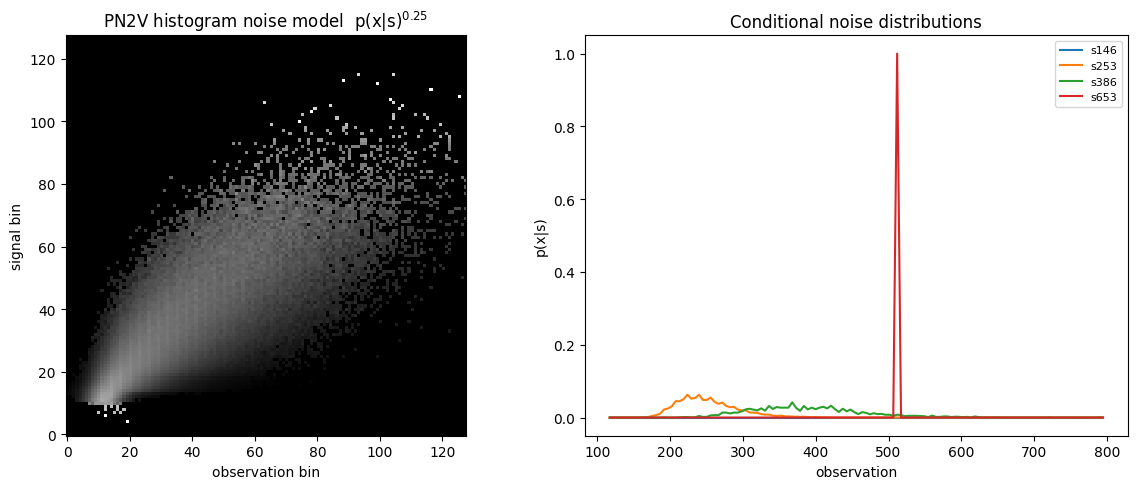

 Noise-model figure saved to /content/drive/MyDrive/DATA_ROOT/exp_data3/PN2V_model/noise_model.png


In [ ]:
minVal = CONFIG["nm_min"] if CONFIG["nm_min"] is not None else float(training_frames.min())
maxVal = CONFIG["nm_max"] if CONFIG["nm_max"] is not None else float(training_frames.max())
bins   = CONFIG["nm_bins"]
CONFIG["nm_min_used"], CONFIG["nm_max_used"] = minVal, maxVal
print(f"Noise model: bins={bins}, range=[{minVal:.1f}, {maxVal:.1f}], "
      f"from {bootstrap_obs.shape[0]} (raw, pseudo-clean) frame pairs.")

histogram = histNoiseModel.createHistogram(bins, minVal, maxVal, bootstrap_obs, bootstrap_signal)
nm_path = os.path.join(PN2V_MODEL_DIR, "noiseModel.npy")
np.save(nm_path, histogram)
noiseModel = histNoiseModel.NoiseModel(histogram, device=device)
print(f" Noise model saved to {nm_path}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(histogram[0] ** 0.25, cmap="gray", origin="lower")
ax[0].set_xlabel("observation bin"); ax[0].set_ylabel("signal bin")
ax[0].set_title("PN2V histogram noise model  p(x|s)$^{0.25}$")
xvals = np.arange(bins) / float(bins) * (maxVal - minVal) + minVal
for idx in [5, 25, 50, 100, 150, 200, 250]:
    if idx < bins:
        s = (idx + 0.5) / float(bins) * (maxVal - minVal) + minVal
        ax[1].plot(xvals, histogram[0][idx, :], label=f"s{s:.0f}")
ax[1].set_xlabel("observation"); ax[1].set_ylabel("p(x|s)")
ax[1].set_title("Conditional noise distributions"); ax[1].legend(fontsize=8)
plt.tight_layout()
nm_fig = os.path.join(PN2V_MODEL_DIR, "noise_model.png")
plt.savefig(nm_fig, dpi=150); plt.show()
print(f" Noise-model figure saved to {nm_fig}")

In [ ]:
bins = histogram.shape[1]
minVal = np.min(histogram[1])
maxVal = np.max(histogram[2])

sig_idx = np.floor(bins * (bootstrap_signal - minVal) / (maxVal - minVal)).astype(int)
sig_idx = np.clip(sig_idx, 0, bins - 1)

counts = np.bincount(sig_idx.ravel(), minlength=bins)

print("nonzero rows:", np.count_nonzero(counts), "of", bins)
print("count percentiles:",
      np.percentile(counts[counts > 0], [0, 1, 5, 10, 50, 90, 99, 100]))

print("rows with <100 pixels:", np.sum((counts > 0) & (counts < 100)))
print("rows with <1000 pixels:", np.sum((counts > 0) & (counts < 1000)))
print("highest row with >=1000 pixels:", np.max(np.where(counts >= 1000)[0]))

nonzero rows: 112 of 128
count percentiles: [1.00000000e+00 1.00000000e+00 1.00000000e+00 2.00000000e+00
 2.85500000e+02 5.59866000e+04 1.67525448e+07 2.27857860e+07]
rows with <100 pixels: 48
rows with <1000 pixels: 67
highest row with >=1000 pixels: 55


Cell 4: Stage 2 — Train the PN2V network (+ logs / config / specs / curves / time)

PN2V TRAINING LOG  |  2026-07-08 22:19:43
Epoch 0 finished      
avg. loss: 2.798414671421051+-(2SEM)0.022246173236725904      
Epoch 1 finished      
avg. loss: 2.8044134855270384+-(2SEM)0.02383277614112422      
Epoch 2 finished      
avg. loss: 2.803442430496216+-(2SEM)0.024707445064917868      
Epoch 3 finished      
avg. loss: 2.789585065841675+-(2SEM)0.026946402202963873      
Epoch 4 finished      
avg. loss: 2.7850910067558288+-(2SEM)0.02467199734879363      
Epoch 5 finished      
avg. loss: 2.7876130819320677+-(2SEM)0.02523868162535657      
Epoch 6 finished      
avg. loss: 2.7953356862068177+-(2SEM)0.028470022851821007      
Epoch 7 finished      
avg. loss: 2.789959490299225+-(2SEM)0.024189864956828722      
Epoch 8 finished      
avg. loss: 2.8087752223014832+-(2SEM)0.017180274281582912      
Epoch 9 finished      
avg. loss: 2.8040847182273865+-(2SEM)0.020413149347184027      
Epoch 10 finished      
avg. loss: 2.7966499805450438+-(2SEM)0.02881495208133026      
Epoch 11

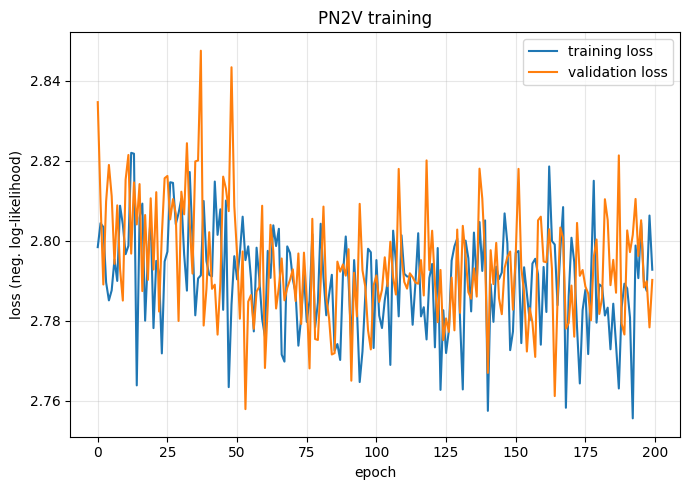

 PN2V training curves saved to /content/drive/MyDrive/DATA_ROOT/exp_data3/PN2V_model/training_curves_PN2V.png


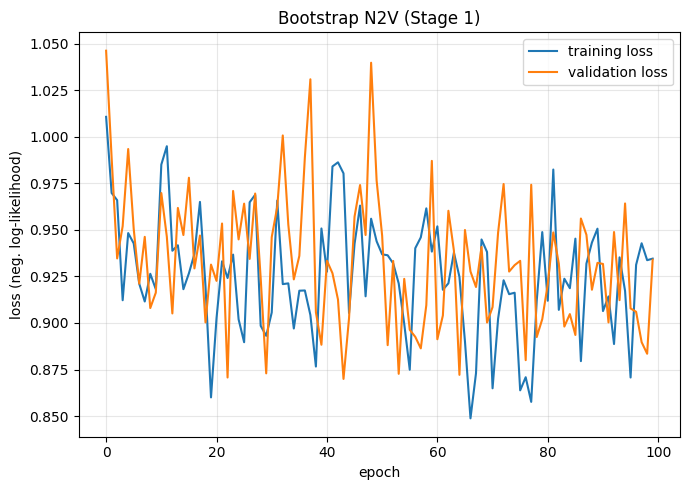

 Full config + specs + timing saved to /content/drive/MyDrive/DATA_ROOT/exp_data3/PN2V_model/pn2v_run_config_and_specs.json
   GPU: NVIDIA A100-SXM4-80GB | total training time: 22.95 min


In [ ]:
class _Tee:
    """Duplicate stdout to both the notebook and a log file (captures the repo's prints)."""
    def __init__(self, *streams): self.streams = streams
    def write(self, data):
        for s in self.streams:
            s.write(data); s.flush()
    def flush(self):
        for s in self.streams: s.flush()

log_path = os.path.join(PN2V_MODEL_DIR, "training_PN2V.log")
log_file = open(log_path, "w")
_old_stdout = sys.stdout
sys.stdout = _Tee(_old_stdout, log_file)

try:
    print("=" * 70)
    print("PN2V TRAINING LOG  |  " + time.strftime("%Y-%m-%d %H:%M:%S"))
    print("=" * 70)

    torch.manual_seed(0); np.random.seed(0)
    pn2v_net = UNet(CONFIG["num_samples"], depth=CONFIG["net_depth"])

    t0 = time.perf_counter()
    pn2v_train_hist, pn2v_val_hist = training.trainNetwork(
        net=pn2v_net, trainData=train_data, valData=val_data,
        noiseModel=noiseModel,                 # <-- PN2V mode
        postfix="pn2v", directory=PN2V_MODEL_DIR, device=device,
        numOfEpochs=CONFIG["pn2v_epochs"], stepsPerEpoch=CONFIG["pn2v_steps"],
        batchSize=CONFIG["batch_size"], patchSize=CONFIG["patch_size_effective"],
        numMaskedPixels=CONFIG["num_masked_pixels"], virtualBatchSize=CONFIG["virtual_batch_size"],
        valSize=CONFIG["val_size"], learningRate=CONFIG["learning_rate"],
        augment=CONFIG["augment"],
    )
    pn2v_time_s = time.perf_counter() - t0
    print(f"\n PN2V training finished in {pn2v_time_s/60:.1f} min ({len(pn2v_train_hist)} epochs).")
finally:
    sys.stdout = _old_stdout
    log_file.close()
print(f"Training log saved to {log_path}")

def _save_curves(train_hist, val_hist, title, path):
    plt.figure(figsize=(7, 5))
    plt.plot(train_hist, label="training loss")
    plt.plot(val_hist, label="validation loss")
    plt.xlabel("epoch"); plt.ylabel("loss (neg. log-likelihood)")
    plt.title(title); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(path, dpi=150); plt.show()

curve_png = os.path.join(PN2V_MODEL_DIR, "training_curves_PN2V.png")
_save_curves(pn2v_train_hist, pn2v_val_hist, "PN2V training", curve_png)
print(f" PN2V training curves saved to {curve_png}")

boot_curve_png = os.path.join(PN2V_MODEL_DIR, "training_curves_bootstrapN2V.png")
_save_curves(boot_train_hist, boot_val_hist, "Bootstrap N2V (Stage 1)", boot_curve_png)

def _versions(pkgs):
    out = {}
    try:
        import importlib.metadata as md
        for p in pkgs:
            try: out[p] = md.version(p)
            except Exception: out[p] = None
    except Exception:
        pass
    return out

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
specs = {
    "method": "PN2V (Probabilistic Noise2Void, Krull et al. 2020)",
    "implementation": "official juglab/pn2v @ 9b7e0f4c3cc6c1c878caff1121585aa15d2f6a33",
    "noise_model": {
        "type": "histogram (bootstrapped)",
        "construction": "Stage-1 N2V (UNet(1) deterministic) pseudo-clean signal vs. raw observations",
        "bins": CONFIG["nm_bins"],
        "range": [CONFIG["nm_min_used"], CONFIG["nm_max_used"]],
        "num_pair_frames": int(bootstrap_obs.shape[0]),
    },
    "data": {
        "train_tiff": TRAIN_TIFF_PATH,
        "train_stack_shape": list(map(int, training_frames.shape)),
        "train_frames": int(train_data.shape[0]),
        "val_frames": int(val_data.shape[0]),
    },
    "hyperparameters": CONFIG,
    "training_time": {
        "bootstrap_n2v_minutes": round(boot_time_s / 60, 2),
        "pn2v_minutes": round(pn2v_time_s / 60, 2),
        "total_minutes": round((boot_time_s + pn2v_time_s) / 60, 2),
    },
    "hardware": {
        "gpu": gpu_name,
        "cuda": torch.version.cuda,
        "cudnn": torch.backends.cudnn.version(),
        "platform": platform.platform(),
        "python": platform.python_version(),
    },
    "versions": _versions(["torch", "torchvision", "numpy", "tifffile", "scipy", "matplotlib"]),
    "final_losses": {
        "pn2v_train_last": float(pn2v_train_hist[-1]) if len(pn2v_train_hist) else None,
        "pn2v_val_last":   float(pn2v_val_hist[-1])   if len(pn2v_val_hist)   else None,
        "pn2v_val_best":   float(np.min(pn2v_val_hist)) if len(pn2v_val_hist) else None,
    },
    "checkpoints": {
        "best": os.path.join(PN2V_MODEL_DIR, "best_pn2v.net"),
        "last": os.path.join(PN2V_MODEL_DIR, "last_pn2v.net"),
        "history_npy": os.path.join(PN2V_MODEL_DIR, "historypn2v.npy"),
        "noise_model": nm_path,
    },
}
specs_path = os.path.join(PN2V_MODEL_DIR, "pn2v_run_config_and_specs.json")
with open(specs_path, "w") as f:
    json.dump(specs, f, indent=2)
np.save(os.path.join(PN2V_MODEL_DIR, "pn2v_train_hist.npy"), np.array(pn2v_train_hist))
np.save(os.path.join(PN2V_MODEL_DIR, "pn2v_val_hist.npy"),   np.array(pn2v_val_hist))

print(f" Full config + specs + timing saved to {specs_path}")
print(f"   GPU: {gpu_name} | total training time: {specs['training_time']['total_minutes']} min")

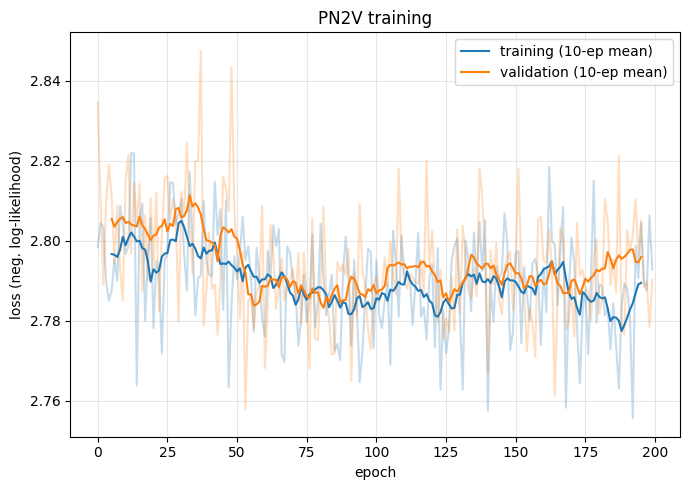

In [ ]:
import numpy as np, matplotlib.pyplot as plt, os
d = "/content/drive/MyDrive/DATA_ROOT/exp_data3/PN2V_model"
tr = np.load(os.path.join(d, "pn2v_train_hist.npy"))
va = np.load(os.path.join(d, "pn2v_val_hist.npy"))
def smooth(x, k=10): return np.convolve(x, np.ones(k)/k, mode="valid")
plt.figure(figsize=(7,5))
plt.plot(tr, color="tab:blue", alpha=0.25); plt.plot(va, color="tab:orange", alpha=0.25)
plt.plot(np.arange(len(smooth(tr)))+5, smooth(tr), color="tab:blue", label="training (10-ep mean)")
plt.plot(np.arange(len(smooth(va)))+5, smooth(va), color="tab:orange", label="validation (10-ep mean)")
plt.xlabel("epoch"); plt.ylabel("loss (neg. log-likelihood)"); plt.title("PN2V training")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(d, "training_curves_PN2V_smoothed.png"), dpi=200); plt.show()

Cell 5: Denoise the test videos with PN2V

In [ ]:
if 'TEST_TIFF_PATHS' in globals():
    print("\n--- Starting PN2V Testing ---")

    if 'noiseModel' not in globals():
        histogram = np.load(os.path.join(PN2V_MODEL_DIR, "noiseModel.npy"))
        noiseModel = histNoiseModel.NoiseModel(histogram, device=device)

    best_ckpt = os.path.join(PN2V_MODEL_DIR, "best_pn2v.net")
    net = torch.load(best_ckpt, map_location=device, weights_only=False)
    net.to(device); net.train(False)
    print(f"Loaded model: {best_ckpt}")

    PAD_DIV = 2 ** (CONFIG["net_depth"] - 1)

    for test_path in TEST_TIFF_PATHS:
        try:
            print(f"\nProcessing: {os.path.basename(test_path)}")
            test_frames = tifffile.imread(test_path).astype(np.float32)
            if test_frames.ndim == 2:
                test_frames = test_frames[np.newaxis, ...]
            base = os.path.splitext(os.path.basename(test_path))[0]
        except Exception as e:
            print(f"  -> ERROR: could not load {test_path}. Skipping.\n   {e}")
            continue

        padded, pads = pad_to_divisible(test_frames, divisor=PAD_DIV)

        print("  -> Denoising frames...")
        mmse_stack, prior_stack = [], []
        for frame in tqdm(padded):
            with torch.no_grad():
                means, mseEst = prediction.predict(frame, net, noiseModel, device, outScaling=10.0)
            mmse_stack.append(mseEst)
            prior_stack.append(means)

        mmse = crop_padded_stack(np.array(mmse_stack, dtype=np.float32), pads)
        mmse_u16 = np.clip(mmse, 0, 65535).astype(np.uint16)
        out_path = os.path.join(OUTPUT_DIR, f"{base}_denoised_PN2V.tif")
        tifffile.imwrite(out_path, mmse_u16, imagej=True)
        print(f"  ->  PN2V (MMSE) saved to: {out_path}")

        if CONFIG["save_prior_output"]:
            prior = crop_padded_stack(np.array(prior_stack, dtype=np.float32), pads)
            prior_u16 = np.clip(prior, 0, 65535).astype(np.uint16)
            prior_path = os.path.join(OUTPUT_DIR, f"{base}_denoised_PN2V-prior.tif")
            tifffile.imwrite(prior_path, prior_u16, imagej=True)
            print(f"  -> (prior / N2V-like) saved to: {prior_path}")
else:
    print(" Test file paths not defined. Run Cell 1 first.")


--- Starting PN2V Testing ---
Loaded model: /content/drive/MyDrive/DATA_ROOT/exp_data3/PN2V_model/best_pn2v.net

Processing: sim_Gauss_Poisson_Est_scale_1.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

  ->  PN2V (MMSE) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_1.00_denoised_PN2V.tif
  -> (prior / N2V-like) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_1.00_denoised_PN2V-prior.tif

Processing: sim_Gauss_Poisson_Est_scale_2.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

  ->  PN2V (MMSE) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_2.00_denoised_PN2V.tif
  -> (prior / N2V-like) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_2.00_denoised_PN2V-prior.tif

Processing: sim_Gauss_Poisson_Est_scale_3.00.tif
  -> Denoising frames...


...

  ->  PN2V (MMSE) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_8.00_denoised_PN2V.tif
  -> (prior / N2V-like) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_8.00_denoised_PN2V-prior.tif

Processing: sim_Gauss_Poisson_Est_scale_9.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

  ->  PN2V (MMSE) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_9.00_denoised_PN2V.tif
  -> (prior / N2V-like) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_9.00_denoised_PN2V-prior.tif

Processing: sim_Gauss_Poisson_Est_scale_10.00.tif
  -> Denoising frames...


  0%|          | 0/916 [00:00<?, ?it/s]

  ->  PN2V (MMSE) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_10.00_denoised_PN2V.tif
  -> (prior / N2V-like) saved to: /content/drive/MyDrive/DATA_ROOT/exp_data3/sim_Gauss_Poisson_Est_scale_10.00_denoised_PN2V-prior.tif


### What this notebook saved:

| File | Purpose |
|---|---|
| `best_pn2v.net`, `last_pn2v.net` | trained PN2V checkpoints (best = lowest val loss) |
| `historypn2v.npy`, `pn2v_train_hist.npy`, `pn2v_val_hist.npy` | raw per-epoch train / val losses |
| `training_curves_PN2V.png` | **training & validation curves** (supplement) |
| `training_curves_bootstrapN2V.png` | Stage-1 curves |
| `training_PN2V.log` | full text training log |
| `pn2v_run_config_and_specs.json` | **all hyper-parameters + hardware specs + training time** |
| `noiseModel.npy`, `noise_model.png` | the bootstrapped noise model + figure |

Denoised videos are written as `*_denoised_PN2V.tif` (and `*_denoised_PN2V-prior.tif`).